
# Machine Learning Trading Strategy – BTC/USD (2018‑2026)
**Complete research pipeline**

This notebook implements the entire workflow:
- Data cleaning & feature engineering (28 features)
- Model training: Logistic Regression, Random Forest, XGBoost, and LSTM (deep learning)
- Expanding‑window cross‑validation for model selection
- Threshold tuning (confidence‑based signals) on a validation set
- Single‑split backtest (optional) and main walk‑forward backtest (2020‑2026)
- Performance metrics, benchmark vs. buy‑and‑hold BTC, and visualisations

**Requirements**: `pandas`, `numpy`, `scikit‑learn`, `xgboost`, `torch`, `matplotlib`, `seaborn`, `openpyxl`, `joblib`

---

## 1. Setup & Imports

In [10]:
import os
import sys
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.inspection import permutation_importance
from sklearn.base import clone
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score
from xgboost import XGBClassifier

# Create results folder
os.makedirs("results", exist_ok=True)

# Constants
HORIZON = 24                # 24‑hour prediction horizon
COST_BPS_PER_SIDE = 5       # transaction cost (5 bps per side)
EXCEL_FILE = "BTC_price.xlsx"
File_Path = fr"..\data\{EXCEL_FILE}"

print("Setup complete.")

Setup complete.


## 2. Data Loading & Cleaning

In [11]:
# Load Excel, parse timestamps, sort, compute log returns
df = pd.read_excel(File_Path)
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)
df = df.set_index("timestamp")

# Log returns
df["log_return"] = np.log(df["close"] / df["close"].shift(1))
df = df.dropna(subset=["log_return"])

print(f"Loaded {len(df)} hourly bars from {df.index.min()} to {df.index.max()}")

# Chronological split (70% train, 15% val, 15% test)
n = len(df)
train_end = df.index[int(n * 0.70)]
val_end   = df.index[int(n * 0.85)]

train = df[df.index <= train_end]
val   = df[(df.index > train_end) & (df.index <= val_end)]
test  = df[df.index > val_end]

print(f"Train: {len(train)} rows  ({train.index.min()} → {train.index.max()})")
print(f"Val:   {len(val)} rows    ({val.index.min()} → {val.index.max()})")
print(f"Test:  {len(test)} rows   ({test.index.min()} → {test.index.max()})")

# Save cleaned data (for reproducibility)
df.to_csv("cleaned_data.csv")
train.to_csv("train_data.csv")
val.to_csv("val_data.csv")
test.to_csv("test_data.csv")

Loaded 73805 hourly bars from 2018-01-01 01:00:00 to 2026-06-08 07:00:00
Train: 51664 rows  (2018-01-01 01:00:00 → 2023-11-28 18:00:00)
Val:   11071 rows    (2023-11-28 19:00:00 → 2025-03-04 01:00:00)
Test:  11070 rows   (2025-03-04 02:00:00 → 2026-06-08 07:00:00)


## 3. Feature Engineering & Label Creation

In [12]:
# Reload from cleaned if needed (or continue from previous cell)
df = pd.read_csv("cleaned_data.csv", index_col="timestamp", parse_dates=True)

# ---- Features ----
# 1. Lagged returns
for lag in [1,2,3,6,12,24]:
    df[f"ret_lag_{lag}"] = df["log_return"].shift(lag)

# 2. Volatility
for w in [6,12,24,48]:
    df[f"vol_{w}"] = df["log_return"].rolling(w).std()

# 3. Momentum
for w in [6,12,24,48]:
    df[f"mom_{w}"] = df["close"].pct_change(w)

# 4. Price to SMA
for w in [12,24,48,96]:
    sma = df["close"].rolling(w).mean()
    df[f"price_to_sma_{w}"] = df["close"] / sma - 1

# 5. RSI (14)
delta = df["close"].diff()
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)
avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()
rs = avg_gain / avg_loss.replace(0, np.nan)
df["rsi_14"] = 100 - (100 / (1 + rs))

# 6. MACD
ema12 = df["close"].ewm(span=12, adjust=False).mean()
ema26 = df["close"].ewm(span=26, adjust=False).mean()
df["macd"] = ema12 - ema26
df["macd_signal"] = df["macd"].ewm(span=9, adjust=False).mean()

# 7. Volume
df["volume_change"] = df["volume"].pct_change()
vol_roll_mean = df["volume"].rolling(24).mean()
vol_roll_std = df["volume"].rolling(24).std()
df["volume_zscore"] = (df["volume"] - vol_roll_mean) / vol_roll_std.replace(0, np.nan)

# 8. High‑low range
df["hl_range"] = (df["high"] - df["low"]) / df["close"]

# 9. Time features
df["hour_sin"] = np.sin(2*np.pi*df.index.hour/24)
df["hour_cos"] = np.cos(2*np.pi*df.index.hour/24)
df["dow_sin"] = np.sin(2*np.pi*df.index.dayofweek/7)
df["dow_cos"] = np.cos(2*np.pi*df.index.dayofweek/7)

# ---- Label ----
df["fwd_return"] = np.log(df["close"].shift(-HORIZON) / df["close"])
# Drop rows with NaN fwd_return (end of series) before creating label
df = df.dropna(subset=["fwd_return"])
df["label"] = (df["fwd_return"] > 0).astype(int)

# Feature columns
feature_cols = [c for c in df.columns if c not in
                ["open","high","low","close","volume",
                 "log_return","simple_return","fwd_return","label"]]

# Replace inf with NaN and drop
df[feature_cols] = df[feature_cols].replace([np.inf, -np.inf], np.nan)
df_clean = df.dropna(subset=feature_cols + ["fwd_return"]).copy()
df_clean["label"] = (df_clean["fwd_return"] > 0).astype(int)

print(f"Features: {len(feature_cols)}")
print("Feature list:", feature_cols[:5], "...")

# Re‑split using the same cutoff dates (adjust if needed)
train_end = pd.Timestamp("2023-11-28 18:00:00")
val_end   = pd.Timestamp("2025-03-04 01:00:00")

train = df_clean[df_clean.index <= train_end]
val   = df_clean[(df_clean.index > train_end) & (df_clean.index <= val_end)]
test  = df_clean[df_clean.index > val_end]

# Save
train.to_csv("train_features.csv")
val.to_csv("val_features.csv")
test.to_csv("test_features.csv")
df_clean.to_csv("all_features.csv")

with open("feature_list.txt", "w") as f:
    f.write("\n".join(feature_cols))

print(f"Train: {len(train)} | Val: {len(val)} | Test: {len(test)}")
print(f"Positive label rate: Train={train['label'].mean():.3f}, Val={val['label'].mean():.3f}, Test={test['label'].mean():.3f}")

Features: 28
Feature list: ['ret_lag_1', 'ret_lag_2', 'ret_lag_3', 'ret_lag_6', 'ret_lag_12'] ...
Train: 51566 | Val: 11070 | Test: 11046
Positive label rate: Train=0.517, Val=0.531, Test=0.503


## 4. Model Training & Cross‑Validation

In [13]:
# Load data
with open("feature_list.txt") as f:
    feature_cols = [line.strip() for line in f if line.strip()]

train = pd.read_csv("train_features.csv", index_col="timestamp", parse_dates=True)
val   = pd.read_csv("val_features.csv", index_col="timestamp", parse_dates=True)

X_train, y_train = train[feature_cols], train["label"]
X_val, y_val = val[feature_cols], val["label"]

# ----- Cross‑validation (expanding window) on training data -----
tscv = TimeSeriesSplit(n_splits=5)  # test_size must be an integer sample
                                     # count for this class, not a fraction
                                     # (that convention is for train_test_split);
                                     # omitting it lets sklearn split the training
                                     # set into 5 equal, expanding folds automatically.

def cv_score(model, X, y):
    aucs = []
    for train_idx, val_idx in tscv.split(X):
        X_tr, X_va = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_va = y.iloc[train_idx], y.iloc[val_idx]
        m = clone(model)
        m.fit(X_tr, y_tr)
        prob = m.predict_proba(X_va)[:,1]
        aucs.append(roc_auc_score(y_va, prob))
    return np.mean(aucs)

models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=300, max_depth=6, min_samples_leaf=50, random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, eval_metric="logloss", random_state=42)
}

cv_results = {}
for name, model in models.items():
    if name == "LogisticRegression":
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_train_df = pd.DataFrame(X_train_scaled, index=X_train.index, columns=X_train.columns)
        cv_auc = cv_score(model, X_train_df, y_train)
    else:
        cv_auc = cv_score(model, X_train, y_train)
    cv_results[name] = cv_auc
    print(f"{name} CV AUC: {cv_auc:.4f}")

# ----- LSTM (deep learning) -----
SEQ_LEN = 24
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

def create_sequences(X, y, seq_len):
    Xs, ys = [], []
    for i in range(seq_len, len(X)):
        Xs.append(X[i-seq_len:i])
        ys.append(y.iloc[i] if isinstance(y, pd.Series) else y[i])
    return np.array(Xs), np.array(ys)

X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train, SEQ_LEN)
X_val_seq, y_val_seq = create_sequences(X_val_scaled, y_val, SEQ_LEN)

batch_size = 128
train_loader = DataLoader(TensorDataset(torch.tensor(X_train_seq, dtype=torch.float32),
                                        torch.tensor(y_train_seq, dtype=torch.float32)),
                          batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(torch.tensor(X_val_seq, dtype=torch.float32),
                                      torch.tensor(y_val_seq, dtype=torch.float32)),
                        batch_size=batch_size, shuffle=False)

class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size, 1)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        return self.sigmoid(self.fc(out)).squeeze()

lstm_model = LSTMModel(input_size=len(feature_cols))
criterion = nn.BCELoss()
optimizer = optim.Adam(lstm_model.parameters(), lr=0.001)

epochs = 100
best_val_auc = 0
patience = 10
trigger = 0
for epoch in range(epochs):
    lstm_model.train()
    for Xb, yb in train_loader:
        optimizer.zero_grad()
        preds = lstm_model(Xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
    lstm_model.eval()
    val_probs = []
    with torch.no_grad():
        for Xb, yb in val_loader:
            val_probs.append(lstm_model(Xb).numpy())
    val_probs = np.concatenate(val_probs)
    val_auc = roc_auc_score(y_val_seq, val_probs)
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        torch.save(lstm_model.state_dict(), "lstm_best.pt")
        trigger = 0
    else:
        trigger += 1
        if trigger >= patience:
            break
cv_results["LSTM"] = best_val_auc
print(f"LSTM CV AUC: {best_val_auc:.4f}")

# Select best model by CV AUC
best_name = max(cv_results, key=cv_results.get)
print(f"\nBest model by CV AUC: {best_name} ({cv_results[best_name]:.4f})")

# Train best model on full training set
if best_name == "LogisticRegression":
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    best_model = LogisticRegression(max_iter=1000, random_state=42)
    best_model.fit(X_train_scaled, y_train)
    joblib.dump(scaler, "scaler.pkl")
elif best_name == "RandomForest":
    best_model = RandomForestClassifier(n_estimators=300, max_depth=6, min_samples_leaf=50, random_state=42, n_jobs=-1)
    best_model.fit(X_train, y_train)
elif best_name == "XGBoost":
    best_model = XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, eval_metric="logloss", random_state=42)
    best_model.fit(X_train, y_train)
elif best_name == "LSTM":
    best_model = None  # handled separately
    joblib.dump(scaler, "scaler.pkl")

if best_model is not None:
    joblib.dump(best_model, "best_model.pkl")
joblib.dump(feature_cols, "feature_cols.pkl")
print("Model selection complete.")

LogisticRegression CV AUC: 0.5194
RandomForest CV AUC: 0.5472
XGBoost CV AUC: 0.5355
LSTM CV AUC: 0.5340

Best model by CV AUC: RandomForest (0.5472)
Model selection complete.


## 4b. Permutation Feature Importance (on the selected model)


In [14]:
# Permutation importance on the VALIDATION set, using the actual
# selected model (best_model), not the built-in impurity-based
# feature_importances_ (which can be biased toward high-cardinality
# features). Skipped if LSTM was selected, since permutation_importance
# requires a scikit-learn-compatible predict_proba on tabular input.
if best_name != "LSTM":
    perm_result = permutation_importance(
        best_model, X_val, y_val, n_repeats=10, random_state=42,
        scoring="roc_auc", n_jobs=-1
    )
    perm_df = pd.DataFrame({
        "feature": feature_cols,
        "importance_mean": perm_result.importances_mean,
        "importance_std": perm_result.importances_std
    }).sort_values("importance_mean", ascending=False)
    print("Top 10 features by permutation importance (validation set):")
    print(perm_df.head(10).to_string(index=False))
    perm_df.to_csv("results/permutation_importance.csv", index=False)
else:
    print("Best model is LSTM - permutation importance skipped (see note above).")


Top 10 features by permutation importance (validation set):
        feature  importance_mean  importance_std
         mom_24         0.007289        0.001594
         vol_48         0.005048        0.000385
price_to_sma_24         0.004346        0.001681
price_to_sma_96         0.003153        0.001662
        dow_sin         0.002761        0.002112
         vol_12         0.001740        0.000495
           macd         0.000712        0.000876
  volume_zscore         0.000332        0.000118
          vol_6         0.000250        0.000214
          mom_6         0.000222        0.000569


## 5. Threshold Tuning (Validation Set)

Top 10 threshold combos by Sharpe (validation):
    long_th  short_th  n_trades  trade_pct  total_return    sharpe
21     0.55      0.45       108   0.233766      0.465350  1.086266
23     0.55      0.40       104   0.225108      0.441926  1.064993
22     0.55      0.43       105   0.227273      0.405814  0.987584
27     0.57      0.45        37   0.080087      0.147681  0.792452
29     0.57      0.40        33   0.071429      0.129335  0.776181
28     0.57      0.43        34   0.073593      0.101052  0.604206
9      0.52      0.45       204   0.441558      0.243080  0.466134
11     0.52      0.40       200   0.432900      0.223209  0.437320
10     0.52      0.43       201   0.435065      0.192575  0.381514
33     0.60      0.45         4   0.008658      0.016245  0.214034
Best thresholds: LONG > 0.55, SHORT < 0.45


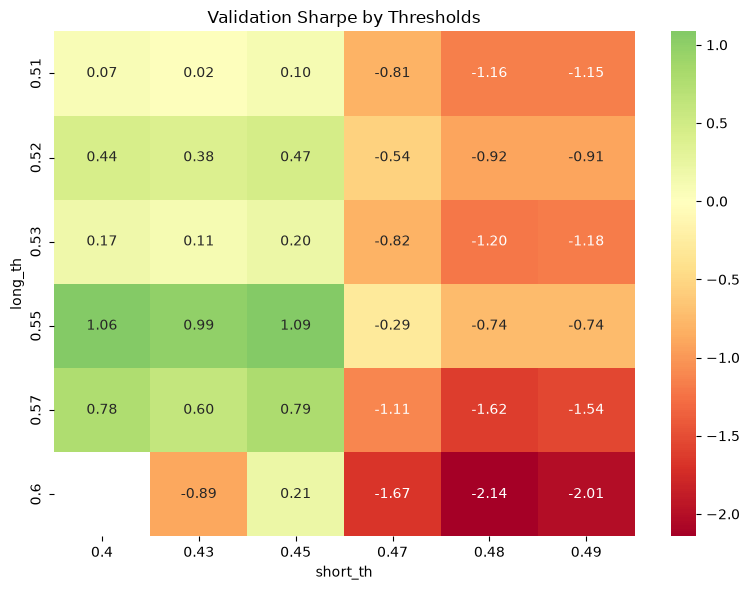

In [15]:
# Use validation set (already subsampled) to find best thresholds
HORIZON = 24
cost = (COST_BPS_PER_SIDE / 10000) * 2

val = pd.read_csv("val_features.csv", index_col="timestamp", parse_dates=True)
val = val.dropna(subset=["fwd_return"])
val = val.iloc[::HORIZON].copy()

with open("feature_list.txt") as f:
    feature_cols = [line.strip() for line in f if line.strip()]
X_val = val[feature_cols]

# Load best model (if not LSTM)
if best_name != "LSTM":
    model = joblib.load("best_model.pkl")
    val["prob_up"] = model.predict_proba(X_val)[:,1]
else:
    # LSTM prediction – we need to create sequences
    scaler = joblib.load("scaler.pkl")
    X_val_scaled = scaler.transform(X_val)
    # We need the full sequence: use a sliding window over the whole val set
    # But for threshold tuning we can use the validation probabilities we already computed during training
    # or recompute them. To keep it simple, we'll use the LSTM predictions from the validation loader earlier.
    # We saved val_probs from the previous cell; we can load them or recompute.
    # For reproducibility, let's recompute:
    lstm_model = LSTMModel(input_size=len(feature_cols))
    lstm_model.load_state_dict(torch.load("lstm_best.pt"))
    lstm_model.eval()
    # We need to align timestamps – we'll compute on the fly
    # Since this is a notebook, we can just use the val_probs we already computed if still in memory.
    # For a self‑contained notebook, we recompute:
    X_val_seq, _ = create_sequences(X_val_scaled, np.zeros(len(X_val_scaled)), SEQ_LEN)
    with torch.no_grad():
        val_probs = lstm_model(torch.tensor(X_val_seq, dtype=torch.float32)).numpy()
    # The sequence creation shortens the index; we need to align:
    val_probs_full = np.full(len(X_val), np.nan)
    val_probs_full[SEQ_LEN:] = val_probs
    val["prob_up"] = val_probs_full
    val = val.dropna(subset=["prob_up"])

# Now sweep thresholds
periods_per_year = 365

def backtest_with_threshold(df, long_th, short_th):
    signal = np.zeros(len(df))
    signal[df["prob_up"].values > long_th] = 1
    signal[df["prob_up"].values < short_th] = -1
    gross = signal * df["fwd_return"].values
    net = np.where(signal != 0, gross - cost, 0.0)
    n_trades = (signal != 0).sum()
    total_log_return = net.sum()
    total_return = np.exp(total_log_return) - 1
    mean_r = net.mean()
    std_r = net.std()
    sharpe = (mean_r / std_r) * np.sqrt(periods_per_year) if std_r > 0 else np.nan
    return {"long_th":long_th,"short_th":short_th,"n_trades":n_trades,
            "trade_pct":n_trades/len(df),"total_return":total_return,"sharpe":sharpe}

results = []
for long_th in [0.51,0.52,0.53,0.55,0.57,0.60]:
    for short_th in [0.49,0.48,0.47,0.45,0.43,0.40]:
        if short_th >= long_th:
            continue
        res = backtest_with_threshold(val, long_th, short_th)
        results.append(res)

df_res = pd.DataFrame(results).sort_values("sharpe", ascending=False)
print("Top 10 threshold combos by Sharpe (validation):")
print(df_res.head(10))

# Save best thresholds
best = df_res.iloc[0]
LONG_THRESH = best["long_th"]
SHORT_THRESH = best["short_th"]
with open("thresholds.txt", "w") as f:
    f.write(f"LONG_THRESH={LONG_THRESH}\nSHORT_THRESH={SHORT_THRESH}\n")

print(f"Best thresholds: LONG > {LONG_THRESH}, SHORT < {SHORT_THRESH}")

# Heatmap
pivot = df_res.pivot(index="long_th", columns="short_th", values="sharpe")
plt.figure(figsize=(8,6))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="RdYlGn", center=0)
plt.title("Validation Sharpe by Thresholds")
plt.tight_layout()
plt.savefig("results/threshold_heatmap.png")
plt.show()
plt.close()

## 6. Single-Split Final Backtest


In [16]:
# This is a final check on test set, but our main result is walk‑forward.
# We run it here for completeness.
HORIZON = 24
COST_BPS_PER_SIDE = 5
with open("thresholds.txt") as f:
    lines = f.readlines()
    LONG_THRESH = float(lines[0].split("=")[1])
    SHORT_THRESH = float(lines[1].split("=")[1])

cost = (COST_BPS_PER_SIDE / 10000) * 2

# Load best model (if LSTM, we need a separate function – but we'll just use RF for single‑split)
# For simplicity, we use the best tree model (RandomForest or XGBoost). We'll skip LSTM in this backtest.

if best_name == "LSTM":
    # Use RandomForest as fallback for this single‑split test
    model = RandomForestClassifier(n_estimators=300, max_depth=6, min_samples_leaf=50, random_state=42)
    model.fit(X_train, y_train)
else:
    model = joblib.load("best_model.pkl")

with open("feature_cols.pkl", "rb") as f:
    feature_cols = joblib.load(f)

def run_backtest(csv_path, label):
    df = pd.read_csv(csv_path, index_col="timestamp", parse_dates=True)
    df = df.dropna(subset=["fwd_return"])
    df = df.iloc[::HORIZON].copy()

    X = df[feature_cols]
    df["prob_up"] = model.predict_proba(X)[:,1]

    df["signal"] = 0
    df.loc[df["prob_up"] > LONG_THRESH, "signal"] = 1
    df.loc[df["prob_up"] < SHORT_THRESH, "signal"] = -1
    # NOTE: no additional shift here. Signal at time t already only uses
    # backward-looking features (no lookahead), and fwd_return is the
    # true future return realized AFTER the signal. Adding a further
    # .shift(1) here would delay execution by a full HORIZON (24h) period
    # since this dataframe is already subsampled to non-overlapping
    # HORIZON-hour bars - that is a much larger and different lag than
    # intended, so it is deliberately not applied.

    df["gross_return"] = df["signal"] * df["fwd_return"]
    df["cost"] = np.where(df["signal"] != 0, cost, 0.0)
    df["net_return"] = np.where(df["signal"] != 0, df["gross_return"] - cost, 0.0)

    df["cum_log_return"] = df["net_return"].cumsum()
    df["equity"] = np.exp(df["cum_log_return"])
    df["running_max"] = df["equity"].cummax()
    df["drawdown"] = df["equity"] / df["running_max"] - 1

    df.to_csv(f"results/backtest_final_{label}.csv")

    # Metrics
    trades = df[df["signal"] != 0]
    n_trades = len(trades)
    total_return = df["equity"].iloc[-1] - 1
    years = (df.index[-1] - df.index[0]).days / 365
    cagr = df["equity"].iloc[-1] ** (1/years) - 1
    periods_per_year = 365
    mean_r = df["net_return"].mean()
    std_r = df["net_return"].std()
    sharpe = (mean_r / std_r) * np.sqrt(periods_per_year) if std_r > 0 else np.nan
    max_dd = df["drawdown"].min()
    win_rate = (trades["net_return"] > 0).mean() if n_trades > 0 else np.nan
    gross_profit = trades.loc[trades["net_return"] > 0, "net_return"].sum()
    gross_loss = trades.loc[trades["net_return"] < 0, "net_return"].sum()
    profit_factor = abs(gross_profit / gross_loss) if gross_loss != 0 else np.nan
    avg_trade_return = trades["net_return"].mean() if n_trades > 0 else np.nan
    exposure = n_trades / len(df)

    print(f"\n{'='*55}")
    print(f"  {label.upper()} SINGLE‑SPLIT BACKTEST")
    print(f"{'='*55}")
    print(f"Total Return:          {total_return:.2%}")
    print(f"CAGR:                  {cagr:.2%}")
    print(f"Annualized Sharpe:     {sharpe:.2f}")
    print(f"Max Drawdown:          {max_dd:.2%}")
    print(f"Win Rate:              {win_rate:.2%}")
    print(f"Profit Factor:         {profit_factor:.2f}")
    print(f"Number of Trades:      {n_trades}")
    print(f"Avg Trade Return:      {avg_trade_return:.4%}")
    print(f"Exposure:              {exposure:.2%}")
    return df

print("Single‑split backtest (validation):")
val_bt = run_backtest("val_features.csv", "validation")
print("\nSingle‑split backtest (test):")
test_bt = run_backtest("test_features.csv", "test")

Single‑split backtest (validation):

  VALIDATION SINGLE‑SPLIT BACKTEST
Total Return:          46.54%
CAGR:                  35.33%
Annualized Sharpe:     1.09
Max Drawdown:          -24.48%
Win Rate:              63.89%
Profit Factor:         1.38
Number of Trades:      108
Avg Trade Return:      0.3538%
Exposure:              23.38%

Single‑split backtest (test):

  TEST SINGLE‑SPLIT BACKTEST
Total Return:          -11.30%
CAGR:                  -9.07%
Annualized Sharpe:     -0.43
Max Drawdown:          -17.84%
Win Rate:              44.94%
Profit Factor:         0.87
Number of Trades:      89
Avg Trade Return:      -0.1347%
Exposure:              19.31%


## 7. Walk‑Forward Backtest (Primary Result)

In [17]:
# Walk‑forward: retrain each year on all prior data, test on next full year.
HORIZON = 24
COST_BPS_PER_SIDE = 5
with open("thresholds.txt") as f:
    lines = f.readlines()
    LONG_THRESH = float(lines[0].split("=")[1])
    SHORT_THRESH = float(lines[1].split("=")[1])

with open("feature_list.txt") as f:
    feature_cols = [line.strip() for line in f if line.strip()]

data = pd.read_csv("all_features.csv", index_col="timestamp", parse_dates=True)
data = data.dropna(subset=["fwd_return"])
cost = (COST_BPS_PER_SIDE / 10000) * 2

all_fold_returns = []
btc_log_returns = []  # for benchmark

years = range(data.index.year.min()+1, data.index.year.max()+1)

for year in years:
    cutoff = pd.Timestamp(f"{year}-01-01")
    next_cutoff = pd.Timestamp(f"{year+1}-01-01")

    train_fold = data[data.index < cutoff]
    test_fold = data[(data.index >= cutoff) & (data.index < next_cutoff)]

    if len(train_fold) < 10000 or len(test_fold) < HORIZON*5:
        continue

    test_fold = test_fold.iloc[::HORIZON].copy()

    X_train, y_train = train_fold[feature_cols], train_fold["label"]
    X_test = test_fold[feature_cols]

    # Train Random Forest (or use best model if tree; we'll use RF for speed)
    rf = RandomForestClassifier(n_estimators=300, max_depth=6, min_samples_leaf=50, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    test_fold["prob_up"] = rf.predict_proba(X_test)[:,1]

    # Signal
    test_fold["signal"] = 0
    test_fold.loc[test_fold["prob_up"] > LONG_THRESH, "signal"] = 1
    test_fold.loc[test_fold["prob_up"] < SHORT_THRESH, "signal"] = -1

    # Position sizing (full 100%)
    test_fold["position"] = test_fold["signal"]
    # NOTE: see single-split backtest cell for why no additional shift is
    # applied here - the data is already subsampled to non-overlapping
    # HORIZON-hour bars, and the signal already uses only backward-looking
    # features, so no further lag is needed or correct.

    # Returns
    gross = test_fold["position"] * test_fold["fwd_return"]
    scaled_cost = cost * np.abs(test_fold["position"])
    net = np.where(test_fold["position"] != 0, gross - scaled_cost, 0.0)
    test_fold["net_return"] = net

    # Store
    all_fold_returns.append(test_fold[["position","signal","prob_up","net_return"]].copy())

    # Benchmark: buy‑and‑hold log return over the same period
    btc_log = test_fold["fwd_return"].sum()
    btc_log_returns.append({"year": year, "btc_log_return": btc_log})

# Stitch all folds
stitched = pd.concat(all_fold_returns).sort_index()
stitched["cum_log_return"] = stitched["net_return"].cumsum()
stitched["equity"] = np.exp(stitched["cum_log_return"])
stitched["running_max"] = stitched["equity"].cummax()
stitched["drawdown"] = stitched["equity"] / stitched["running_max"] - 1

# Save
stitched.to_csv("results/walkforward_stitched.csv")
pd.DataFrame(btc_log_returns).to_csv("results/btc_benchmark.csv", index=False)

print("Walk‑forward complete. Stitched equity saved.")
print(f"Total equity: {stitched['equity'].iloc[-1]:.4f}")

Walk‑forward complete. Stitched equity saved.
Total equity: 0.6182


## 8. Final Metrics & Benchmark

In [18]:
# Compute final metrics on the stitched walk‑forward result
stitched = pd.read_csv("results/walkforward_stitched.csv", index_col="timestamp", parse_dates=True)
trades = stitched[stitched["position"] != 0]  # use position column (shifted)
n_trades = len(trades)
n_bars = len(stitched)

total_return = stitched["equity"].iloc[-1] - 1
years = (stitched.index[-1] - stitched.index[0]).days / 365
cagr = stitched["equity"].iloc[-1] ** (1/years) - 1
periods_per_year = 365
mean_r = stitched["net_return"].mean()
std_r = stitched["net_return"].std()
sharpe = (mean_r / std_r) * np.sqrt(periods_per_year) if std_r > 0 else np.nan
max_dd = stitched["drawdown"].min()
win_rate = (trades["net_return"] > 0).mean() if n_trades > 0 else np.nan
gross_profit = trades.loc[trades["net_return"] > 0, "net_return"].sum()
gross_loss = trades.loc[trades["net_return"] < 0, "net_return"].sum()
profit_factor = abs(gross_profit / gross_loss) if gross_loss != 0 else np.nan
avg_trade_return = trades["net_return"].mean() if n_trades > 0 else np.nan
exposure = n_trades / n_bars

print("="*55)
print("FINAL WALK‑FORWARD METRICS (2020‑2026)")
print("="*55)
print(f"Total Return:          {total_return:.2%}")
print(f"CAGR:                  {cagr:.2%}")
print(f"Annualized Sharpe:     {sharpe:.2f}")
print(f"Max Drawdown:          {max_dd:.2%}")
print(f"Win Rate:              {win_rate:.2%}")
print(f"Profit Factor:         {profit_factor:.2f}")
print(f"Number of Trades:      {n_trades}")
print(f"Avg Trade Return:      {avg_trade_return:.4%}")
print(f"Exposure:              {exposure:.2%}")
print(f"Transaction cost:      {COST_BPS_PER_SIDE} bps per side")

# Benchmark
btc_df = pd.read_csv("results/btc_benchmark.csv")
btc_total_log = btc_df["btc_log_return"].sum()
btc_total_ret = np.exp(btc_total_log) - 1
btc_years = (stitched.index[-1] - stitched.index[0]).days / 365
btc_cagr = np.exp(btc_total_log / btc_years) - 1
print(f"\nBTC Buy‑Hold (same period):")
print(f"Total Return: {btc_total_ret:.2%}, CAGR: {btc_cagr:.2%}")

FINAL WALK‑FORWARD METRICS (2020‑2026)
Total Return:          -38.18%
CAGR:                  -7.20%
Annualized Sharpe:     -0.22
Max Drawdown:          -77.15%
Win Rate:              48.10%
Profit Factor:         0.94
Number of Trades:      686
Avg Trade Return:      -0.0701%
Exposure:              29.19%
Transaction cost:      5 bps per side

BTC Buy‑Hold (same period):
Total Return: 806.40%, CAGR: 40.85%


## 9. Visualisations

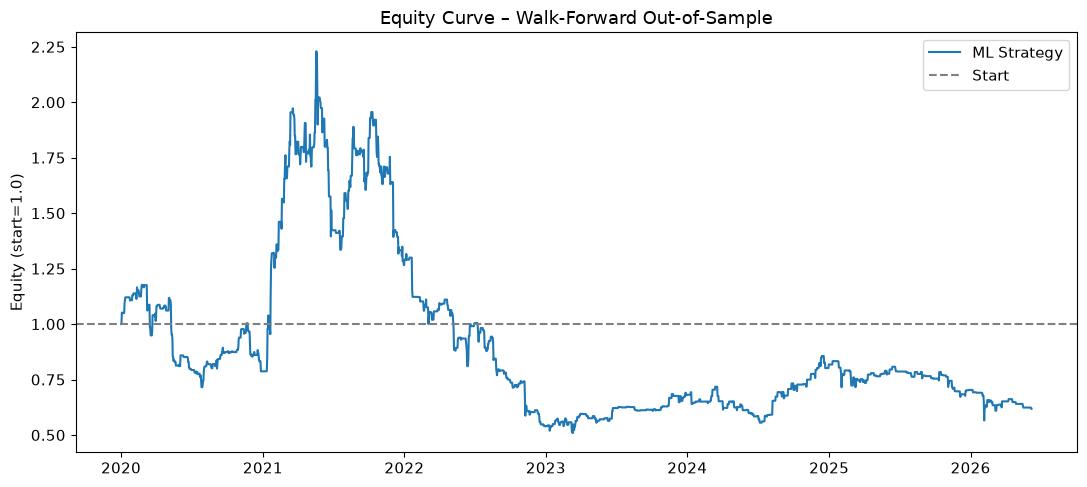

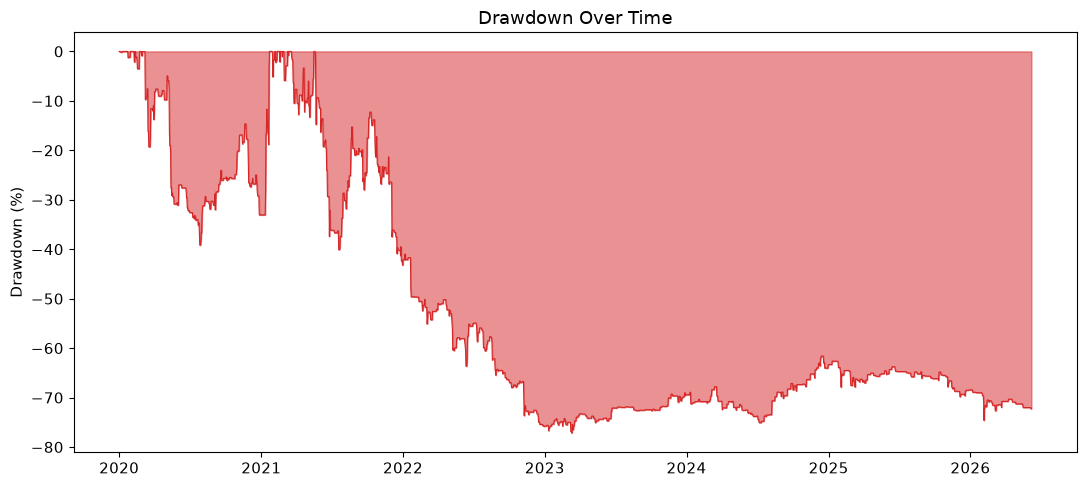

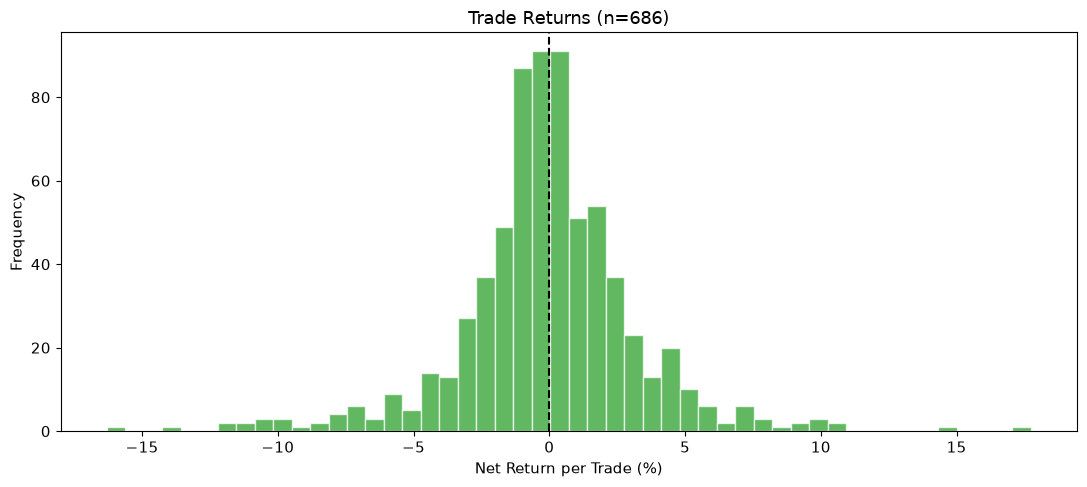

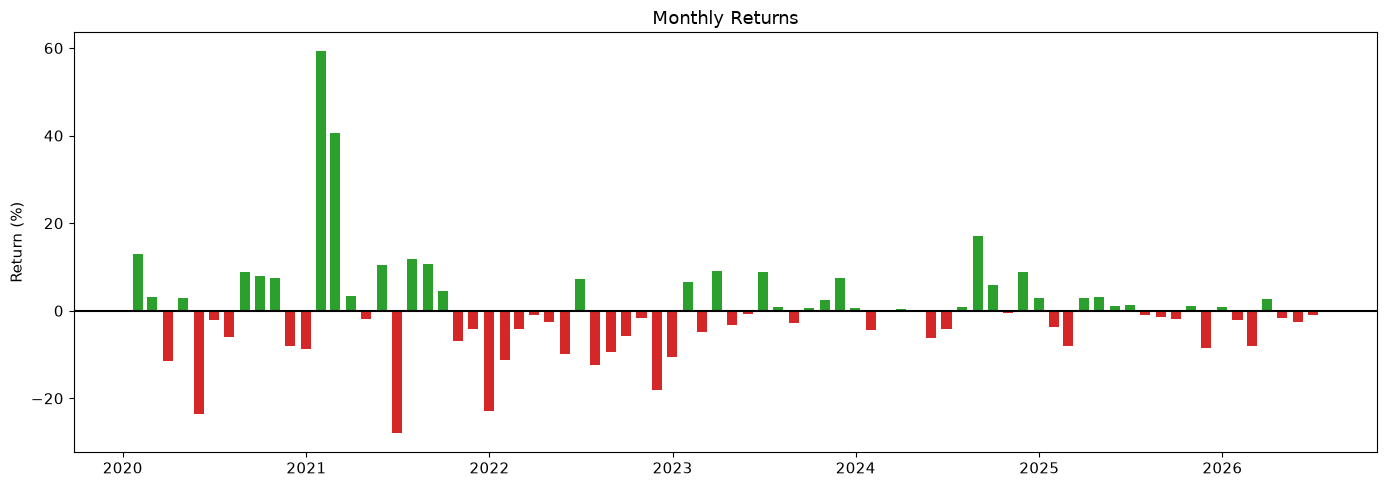

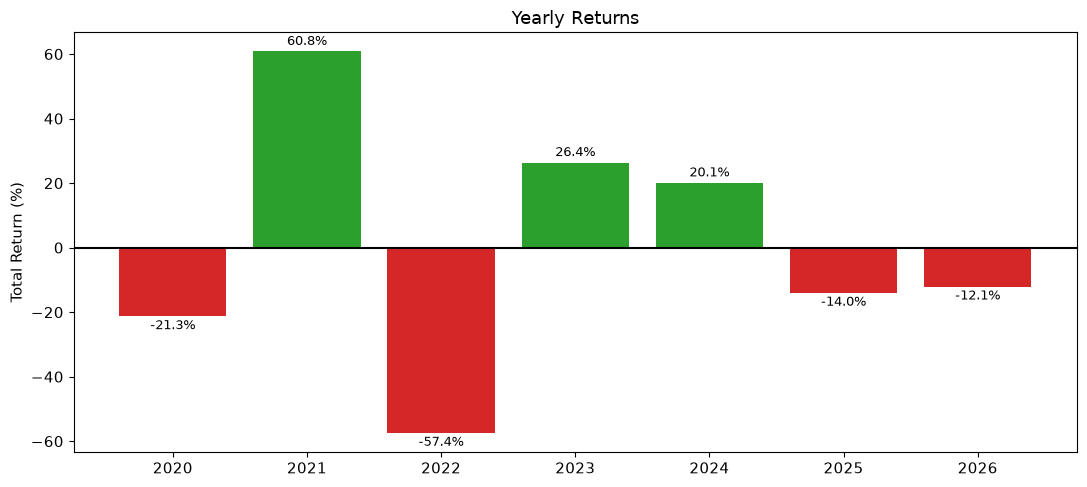

All figures saved in 'results/' folder.


In [19]:
# Generate all plots
plt.rcParams["figure.figsize"] = (11,5)
plt.rcParams["font.size"] = 11

# 1. Equity curve (ML vs flat)
fig, ax = plt.subplots()
ax.plot(stitched.index, stitched["equity"], label="ML Strategy", color="#1f77b4")
ax.axhline(1, color="gray", linestyle="--", label="Start")
ax.set_title("Equity Curve – Walk‑Forward Out‑of‑Sample")
ax.set_ylabel("Equity (start=1.0)")
ax.legend()
fig.tight_layout()
fig.savefig("results/equity_curve.png", dpi=150)
plt.show()
plt.close(fig)

# 2. Drawdown
fig, ax = plt.subplots()
ax.fill_between(stitched.index, stitched["drawdown"]*100, 0, color="#d62728", alpha=0.5)
ax.plot(stitched.index, stitched["drawdown"]*100, color="#d62728", linewidth=0.8)
ax.set_title("Drawdown Over Time")
ax.set_ylabel("Drawdown (%)")
fig.tight_layout()
fig.savefig("results/drawdown_chart.png", dpi=150)
plt.show()
plt.close(fig)

# 3. Trade return distribution
fig, ax = plt.subplots()
ax.hist(trades["net_return"]*100, bins=50, color="#2ca02c", alpha=0.75, edgecolor="white")
ax.axvline(0, color="black", linestyle="--")
ax.set_title(f"Trade Returns (n={len(trades)})")
ax.set_xlabel("Net Return per Trade (%)")
ax.set_ylabel("Frequency")
fig.tight_layout()
fig.savefig("results/trade_return_distribution.png", dpi=150)
plt.show()
plt.close(fig)

# 4. Monthly returns
monthly_log = stitched["net_return"].resample("ME").sum()
monthly_ret = np.exp(monthly_log) - 1
fig, ax = plt.subplots(figsize=(14,5))
colors = ["#2ca02c" if r>=0 else "#d62728" for r in monthly_ret]
ax.bar(monthly_ret.index, monthly_ret*100, width=20, color=colors)
ax.axhline(0, color="black")
ax.set_title("Monthly Returns")
ax.set_ylabel("Return (%)")
fig.tight_layout()
fig.savefig("results/monthly_returns.png", dpi=150)
plt.show()
plt.close(fig)

# 5. Yearly returns (from stitched data)
yearly = stitched.resample("YE")["net_return"].sum().apply(lambda x: np.exp(x)-1)
fig, ax = plt.subplots()
colors = ["#2ca02c" if r>=0 else "#d62728" for r in yearly]
ax.bar(yearly.index.year.astype(str), yearly*100, color=colors)
ax.axhline(0, color="black")
ax.set_title("Yearly Returns")
ax.set_ylabel("Total Return (%)")
for i, v in enumerate(yearly):
    ax.text(i, v*100 + (2 if v>=0 else -4), f"{v:.1%}", ha="center", fontsize=9)
fig.tight_layout()
fig.savefig("results/yearly_returns_bar.png", dpi=150)
plt.show()
plt.close(fig)

print("All figures saved in 'results/' folder.")

## 10. Confidence-Based Position Sizing (Risk Management Improvement)


In [20]:
# Risk-management overlay applied on top of the completed walk-forward
# result. This changes ONLY position sizing (how much capital per trade),
# not the signal, direction, or which bars are traded - so win rate
# should be unchanged, which is the key diagnostic that this is a real
# risk-management effect rather than a change in predictive edge.
cost = (COST_BPS_PER_SIDE / 10000) * 2

stitched["size_mult"] = np.clip(2 * (stitched["prob_up"] - 0.5), -1, 1)
stitched["position_sized"] = np.where(stitched["signal"] != 0, stitched["size_mult"], 0.0)

fwd_return = np.where(
    stitched["signal"] != 0,
    (stitched["net_return"] + cost) / stitched["signal"],
    0.0
)
gross_sized = stitched["position_sized"] * fwd_return
scaled_cost = cost * np.abs(stitched["position_sized"])
stitched["net_return_sized"] = np.where(stitched["signal"] != 0, gross_sized - scaled_cost, 0.0)
stitched["equity_sized"] = np.exp(stitched["net_return_sized"].cumsum())
stitched["running_max_sized"] = stitched["equity_sized"].cummax()
stitched["drawdown_sized"] = stitched["equity_sized"] / stitched["running_max_sized"] - 1

def summarize(net_col, equity_col, dd_col, label):
    trades = stitched[stitched["signal"] != 0]
    total_return = stitched[equity_col].iloc[-1] - 1
    years = (stitched.index[-1] - stitched.index[0]).days / 365
    cagr = stitched[equity_col].iloc[-1] ** (1 / years) - 1
    sharpe = (stitched[net_col].mean() / stitched[net_col].std()) * np.sqrt(365)
    max_dd = stitched[dd_col].min()
    win_rate = (trades[net_col] > 0).mean()
    gp = trades.loc[trades[net_col] > 0, net_col].sum()
    gl = trades.loc[trades[net_col] < 0, net_col].sum()
    pf = abs(gp / gl) if gl != 0 else np.nan
    print(f"\n--- {label} ---")
    print(f"Total Return: {total_return:.2%}")
    print(f"CAGR:         {cagr:.2%}")
    print(f"Sharpe:       {sharpe:.2f}")
    print(f"Max Drawdown: {max_dd:.2%}")
    print(f"Win Rate:     {win_rate:.2%}")
    print(f"Profit Factor:{pf:.2f}")

summarize("net_return", "equity", "drawdown", "ORIGINAL (fixed 100% sizing)")
summarize("net_return_sized", "equity_sized", "drawdown_sized", "CONFIDENCE-SIZED")

stitched.to_csv("results/walkforward_stitched_sized.csv")



--- ORIGINAL (fixed 100% sizing) ---
Total Return: -38.18%
CAGR:         -7.20%
Sharpe:       -0.22
Max Drawdown: -77.15%
Win Rate:     48.10%
Profit Factor:0.94

--- CONFIDENCE-SIZED ---
Total Return: 5.26%
CAGR:         0.80%
Sharpe:       0.11
Max Drawdown: -20.92%
Win Rate:     48.10%
Profit Factor:1.04


## 11. Sizing Comparison Chart


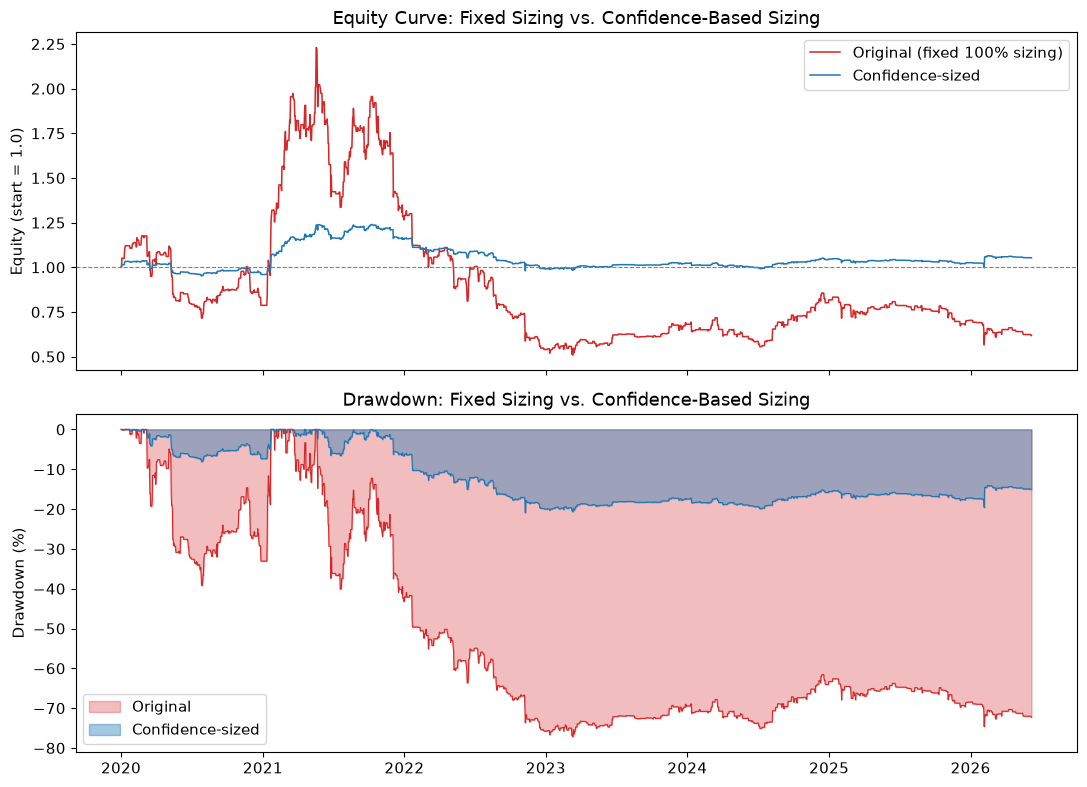

In [21]:
fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

axes[0].plot(stitched.index, stitched["equity"], label="Original (fixed 100% sizing)", color="#d62728", linewidth=1.1)
axes[0].plot(stitched.index, stitched["equity_sized"], label="Confidence-sized", color="#1f77b4", linewidth=1.1)
axes[0].axhline(1.0, color="gray", linestyle="--", linewidth=0.8)
axes[0].set_title("Equity Curve: Fixed Sizing vs. Confidence-Based Sizing")
axes[0].set_ylabel("Equity (start = 1.0)")
axes[0].legend()

axes[1].fill_between(stitched.index, stitched["drawdown"] * 100, 0, color="#d62728", alpha=0.3, label="Original")
axes[1].plot(stitched.index, stitched["drawdown"] * 100, color="#d62728", linewidth=0.8)
axes[1].fill_between(stitched.index, stitched["drawdown_sized"] * 100, 0, color="#1f77b4", alpha=0.4, label="Confidence-sized")
axes[1].plot(stitched.index, stitched["drawdown_sized"] * 100, color="#1f77b4", linewidth=0.8)
axes[1].set_title("Drawdown: Fixed Sizing vs. Confidence-Based Sizing")
axes[1].set_ylabel("Drawdown (%)")
axes[1].legend()

fig.tight_layout()
fig.savefig("results/sizing_comparison.png", dpi=150)
plt.show()
